In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

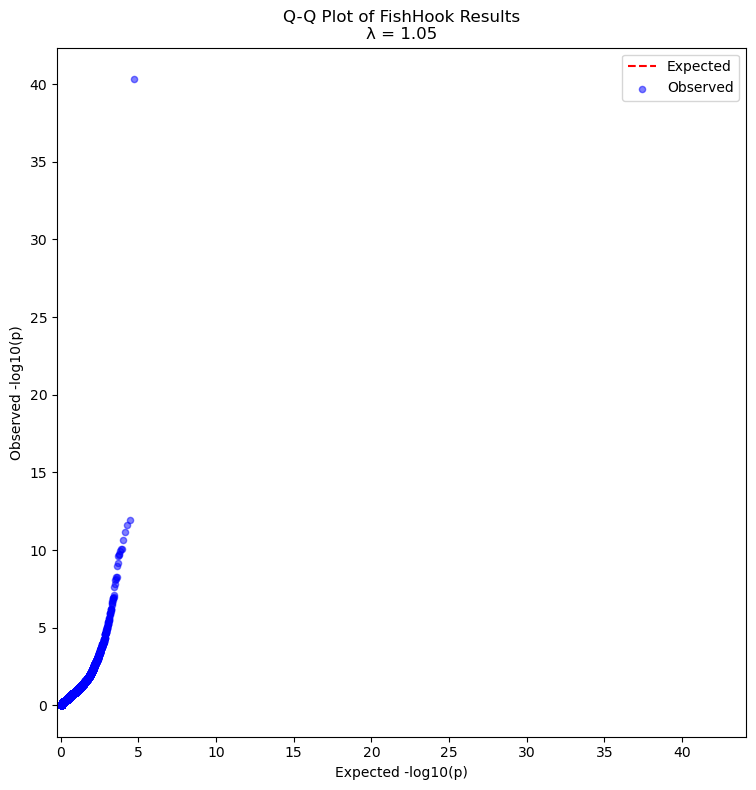

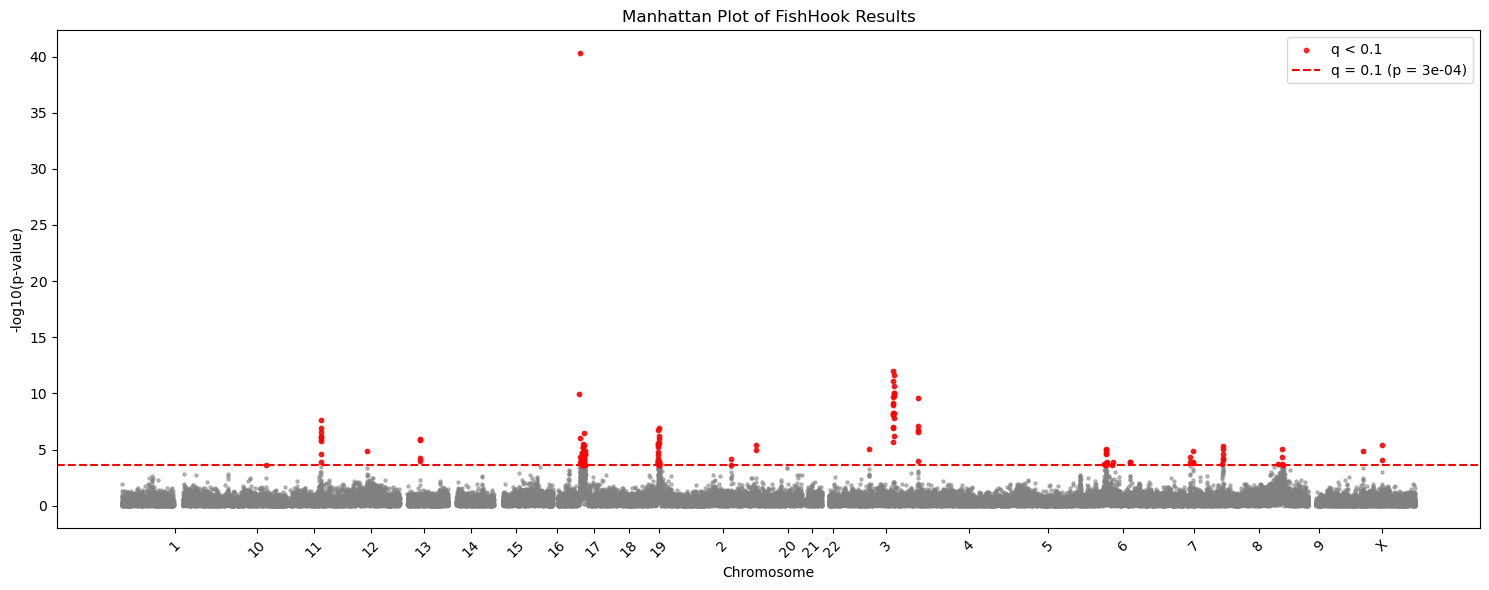

Number of significant regions (p < 0.05): 2284
Number of significant regions (q < 0.1): 152
Maximum -log10(p-value): 40.32

Top 10 significant regions:
      chr      start        end  count        pvalue        qvalue  \
0   chr17    7675001    7725000     91  4.800000e-41  2.600000e-36   
1    chr3  116575001  116625000     27  1.100000e-12  3.000000e-08   
2    chr3  117175001  117225000     26  2.300000e-12  4.200000e-08   
3    chr3  116775001  116825000     25  7.200000e-12  9.900000e-08   
4    chr3  117025001  117075000     24  2.100000e-11  2.300000e-07   
5    chr3  117225001  117275000     23  8.400000e-11  7.000000e-07   
6    chr3  117125001  117175000     24  8.900000e-11  7.000000e-07   
7   chr17    7625001    7675000     26  1.100000e-10  7.600000e-07   
9    chr3  116825001  116875000     22  2.200000e-10  1.200000e-06   
10   chr3  175125001  175175000     21  2.500000e-10  1.200000e-06   

    fold_change  
0     65.467626  
1     21.951220  
2     22.222222  
3    

In [2]:
# Q-Q plot
def make_qq_plot(pvalues):
    # Remove NAs & sort p-values
    pvalues = pvalues.dropna()
    pvalues = pvalues[(pvalues > 0) & (pvalues < 1)]
    
    # Calculate observed values
    observed = -np.log10(np.sort(pvalues))
    
    # Calculate expected values under null (uniform distribution)
    n = len(pvalues)
    expected = -np.log10(np.arange(1, n + 1) / (n + 1))
    
    # Calculate lambda (genomic inflation factor), lamda = 1 so little to no inflation 
    chi2_obs = stats.chi2.ppf(1 - pvalues, df=1)
    lambda_gc = np.median(chi2_obs) / stats.chi2.ppf(0.5, df=1) # divide median of observed test statistics by expected median 
    
    plt.figure(figsize=(8, 8))
    
    # Plot expected line (up to 95th percentile of expected values)
    max_exp = np.percentile(expected, 95)
    plt.plot([0, max_exp], [0, max_exp], 'r--', 
             label='Expected', linewidth=1.5, zorder=1)
    
    # Plot observed points
    plt.scatter(expected, observed, alpha=0.5, label='Observed', s=20, color='blue', zorder=2)
    
    plt.xlabel('Expected -log10(p)')
    plt.ylabel('Observed -log10(p)')
    plt.title(f'Q-Q Plot of FishHook Results\nλ = {lambda_gc:.2f}')
    plt.legend()
    
    max_plot = max(np.percentile(observed, 99), max_exp)
    plt.xlim(0, max_plot)
    plt.ylim(0, max_plot)
    
    plt.axis('square')
    plt.tight_layout()
    
    plt.show()
    plt.close()
    
# Manhattan Plot
def make_manhattan_plot(results):
    # Convert chr names to numeric
    results['chr_num'] = results['chr'].str.replace('chr', '').astype(str)
    
    # Calculate cumulative position for x-axis
    chrom_lengths = results.groupby('chr')['end'].max().reset_index()
    chrom_lengths['cumsum'] = chrom_lengths['end'].cumsum()
    chrom_lengths['prev_cumsum'] = chrom_lengths['cumsum'].shift(1).fillna(0)
    
    # Add cumulative position to results
    results = results.merge(chrom_lengths[['chr', 'prev_cumsum']], on='chr')
    results['plot_pos'] = results['start'] + results['prev_cumsum']
    

    plt.figure(figsize=(15, 6))
    
    plt.scatter(results['plot_pos'], -np.log10(results['pvalue']), c='grey', s=5, alpha=0.5)
    
    # plot significant points (q < 0.1) in red
    significant = results[results['qvalue'] < 0.1]
    plt.scatter(significant['plot_pos'], -np.log10(significant['pvalue']), c='red', s=10, alpha=0.8, label='q < 0.1')
    
    # significance line for q < 0.1 (using the minimum p-value that corresponds to q < 0.1)
    sig_threshold = -np.log10(results[results['qvalue'] < 0.1]['pvalue'].max())
    plt.axhline(y=sig_threshold, color='red', linestyle='--', label=f'q = 0.1 (p = {10**-sig_threshold:.0e})')
    
    plt.xlabel('Chromosome')
    plt.ylabel('-log10(p-value)')
    plt.title('Manhattan Plot of FishHook Results')
    
    tick_positions = chrom_lengths.apply(lambda x: x['prev_cumsum'] + x['end']/2, axis=1)
    plt.xticks(tick_positions, chrom_lengths['chr'].str.replace('chr', ''), rotation=45)
    
    plt.legend()
    plt.tight_layout()
    
    plt.show()
    plt.close()

results = pd.read_csv('../results/fishhook_results.txt', sep='\t')
make_qq_plot(results['pvalue'])
make_manhattan_plot(results)

# stats & top 10 significant regions
print(f"Number of significant regions (p < 0.05): {sum(results['pvalue'] < 0.05)}")
print(f"Number of significant regions (q < 0.1): {sum(results['qvalue'] < 0.1)}")
print(f"Maximum -log10(p-value): {-np.log10(results['pvalue'].min()):.2f}")
print("\nTop 10 significant regions:")
print(results.sort_values('qvalue').head(10)[['chr', 'start', 'end', 'count', 'pvalue', 'qvalue', 'fold_change']])

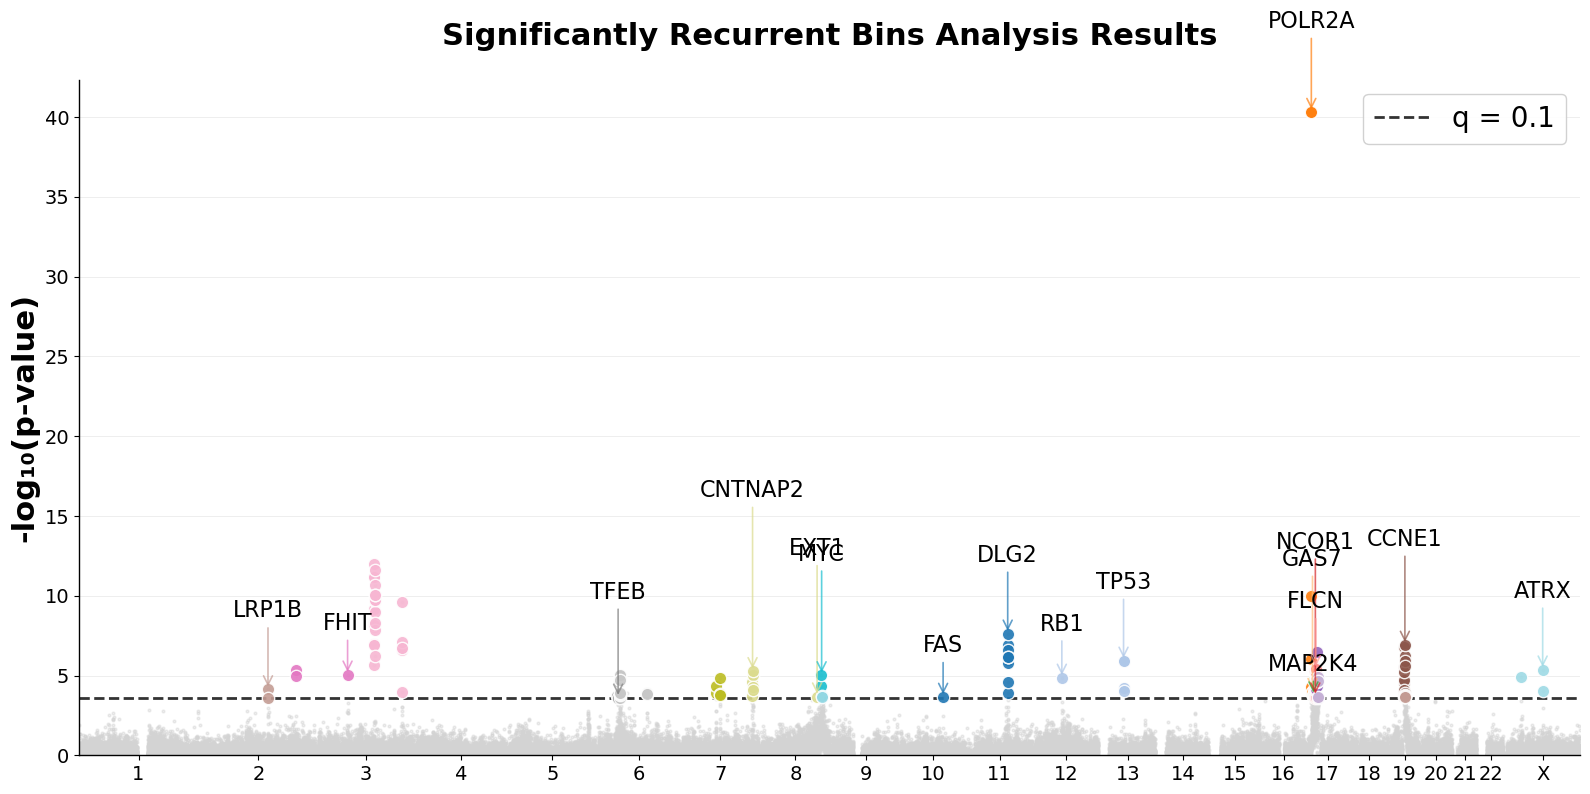


Plot Diagnostics:
Total chromosomes plotted: 23
Chromosomes with clusters: 12
Total TAD clusters: 44

TAD Cluster Summary:

TAD 0 (chr10:87800000-89000000):
Number of SRBs: 1
COSMIC genes: FAS,PTEN

TAD 1 (chr11:83850000-84650000):
Number of SRBs: 9
COSMIC genes: 

TAD 2 (chr11:84650000-85600000):
Number of SRBs: 1
COSMIC genes: 

TAD 3 (chr12:56700000-57800000):
Number of SRBs: 1
COSMIC genes: CDK4,DDIT3,GLI1,NAB2,NACA,STAT6

TAD 4 (chr13:48150000-48800000):
Number of SRBs: 4
COSMIC genes: CYSLTR2,RB1

TAD 5 (chr17:7200000-7700000):
Number of SRBs: 2
COSMIC genes: POLR2A,TP53

TAD 6 (chr17:7700000-8050000):
Number of SRBs: 3
COSMIC genes: 

TAD 7 (chr17:8900000-9600000):
Number of SRBs: 1
COSMIC genes: 

TAD 8 (chr17:9800000-10650000):
Number of SRBs: 1
COSMIC genes: GAS7

TAD 9 (chr17:12000000-12150000):
Number of SRBs: 1
COSMIC genes: MAP2K4

TAD 10 (chr17:12150000-13050000):
Number of SRBs: 2
COSMIC genes: 

TAD 11 (chr17:13050000-14300000):
Number of SRBs: 5
COSMIC genes: 

TAD 1

In [ ]:
srbs = results[results['qvalue'] < 0.1].copy()

# Read TAD data
tads = pd.read_csv('../data/hg38_ref_files/TADMap_scaffold_hs.bed.txt', sep='\s+', names=['chr', 'start', 'end'])

# Read COSMIC data
cosmic = pd.read_csv('../data/hg38_ref_files/Cosmic_CancerGeneCensus_v102_GRCh38.tsv', sep='\t')
if not cosmic['CHROMOSOME'].astype(str).str.startswith('chr').any():
    cosmic['CHROMOSOME'] = 'chr' + cosmic['CHROMOSOME'].astype(str)

def cluster_srbs_in_tads(srbs, tads, cosmic):
    """
    Group SRBs by TADs and annotate with COSMIC genes in the entire TAD
    """
    tad_clusters = []
    current_cluster = 0
    
    for _, tad in tads.iterrows():
        # Find SRBs in this TAD
        tad_srbs = srbs[
            (srbs['chr'] == tad['chr']) &
            (srbs['start'] <= tad['end']) &
            (srbs['end'] >= tad['start'])
        ]
        
        if len(tad_srbs) > 0:
            # Find COSMIC genes in this TAD
            tad_genes = cosmic[
                (cosmic['CHROMOSOME'] == tad['chr']) &
                (cosmic['GENOME_START'] <= tad['end']) &
                (cosmic['GENOME_STOP'] >= tad['start'])
            ]
            
            # Assign cluster info to SRBs
            tad_srbs = tad_srbs.copy()
            tad_srbs['tad_cluster'] = current_cluster
            tad_srbs['tad_start'] = tad['start']
            tad_srbs['tad_end'] = tad['end']
            tad_srbs['tad_genes'] = ','.join(tad_genes['GENE_SYMBOL']) if len(tad_genes) > 0 else ''
            tad_srbs['tad_gene_count'] = len(tad_genes)
            
            tad_clusters.append(tad_srbs)
            current_cluster += 1
    
    if tad_clusters:
        return pd.concat(tad_clusters)
    return pd.DataFrame()

def make_manhattan_plot_with_tad_clusters(results, clustered_srbs):
    """
    Create Manhattan plot with TAD clusters
    """
    # Define proper chromosome order
    chr_order = [str(i) for i in range(1, 23)] + ['X']
    
    # Function to convert chromosome to sortable format
    def chr_to_sort_key(chr_str):
        chr_clean = chr_str.replace('chr', '')
        if chr_clean == 'X':
            return 23
        elif chr_clean == 'Y':
            return 24
        else:
            return int(chr_clean)
    
    # Create copies to avoid modifying original data
    results_plot = results.copy()
    clustered_srbs_plot = clustered_srbs.copy()
    
    # Add sortable chromosome column
    results_plot['chr_sort'] = results_plot['chr'].apply(chr_to_sort_key)
    clustered_srbs_plot['chr_sort'] = clustered_srbs_plot['chr'].apply(chr_to_sort_key)
    
    # Sort by chromosome order
    results_plot = results_plot.sort_values(['chr_sort', 'start'])
    clustered_srbs_plot = clustered_srbs_plot.sort_values(['chr_sort', 'start'])
    
    # Calculate cumulative positions with consistent gaps
    chrom_info = []
    cumulative_pos = 0
    gap_size = 5000000  # 5 Mb gap between chromosomes
    
    # Process chromosomes in order, only including those with data
    for chr_num in chr_order:
        chr_name = f'chr{chr_num}'
        chr_data = results_plot[results_plot['chr'] == chr_name]
        
        if len(chr_data) > 0:
            chr_length = chr_data['end'].max()
            chr_start = cumulative_pos
            chr_end = cumulative_pos + chr_length
            chr_center = chr_start + chr_length / 2
            
            chrom_info.append({
                'chr': chr_name,
                'chr_num': chr_num,
                'chr_sort': chr_to_sort_key(chr_name),
                'start_pos': chr_start,
                'end_pos': chr_end,
                'center_pos': chr_center,
                'length': chr_length
            })
            
            # Add cumulative position to data
            results_plot.loc[results_plot['chr'] == chr_name, 'plot_pos'] = \
                chr_start + results_plot.loc[results_plot['chr'] == chr_name, 'start']
            
            # Only update clustered_srbs if this chromosome has clustered data
            chr_clustered = clustered_srbs_plot[clustered_srbs_plot['chr'] == chr_name]
            if len(chr_clustered) > 0:
                clustered_srbs_plot.loc[clustered_srbs_plot['chr'] == chr_name, 'plot_pos'] = \
                    chr_start + clustered_srbs_plot.loc[clustered_srbs_plot['chr'] == chr_name, 'start']
            
            cumulative_pos = chr_end + gap_size
    
    chrom_df = pd.DataFrame(chrom_info)
    
    # Create the plot with better proportions
    plt.figure(figsize=(16, 8))
    
    # Plot all points in grey with lower opacity
    plt.scatter(results_plot['plot_pos'], 
               -np.log10(results_plot['pvalue']),
               c='lightgrey',
               s=4,
               alpha=0.4)
    
    # Use darker colors for clusters
    unique_clusters = sorted(clustered_srbs_plot['tad_cluster'].unique())
    colors = plt.cm.Dark2(np.linspace(0, 1, min(len(unique_clusters), 8)))
    if len(unique_clusters) > 8:
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))
    
    # Plot clusters with enhanced visibility
    all_cluster_data = list(enumerate(clustered_srbs_plot.groupby('tad_cluster')))
    
    for i, (cluster_id, cluster_data) in all_cluster_data:
        color_idx = i % len(colors)
        
        # Plot cluster points with darker colors and better visibility
        plt.scatter(cluster_data['plot_pos'],
                   -np.log10(cluster_data['pvalue']),
                   c=[colors[color_idx]],
                   s=80,  # Larger points
                   alpha=0.9,  # More opaque
                   edgecolors='white',
                   linewidth=1.0,
                   zorder=5)  # Ensure clusters are on top
        
        # Add gene labels with smart positioning
        if cluster_data['tad_genes'].iloc[0] or cluster_id == 1:
            tad_start = cluster_data['tad_start'].iloc[0]
            tad_end = cluster_data['tad_end'].iloc[0]
            tad_chr = cluster_data['chr'].iloc[0]
            
            # Calculate label position
            if 'plot_pos' in cluster_data.columns and not cluster_data['plot_pos'].isna().all():
                tad_mid_pos = cluster_data['plot_pos'].mean()
            else:
                # Fallback calculation
                chr_info = chrom_df[chrom_df['chr'] == tad_chr]
                if len(chr_info) > 0:
                    chr_start = chr_info['start_pos'].iloc[0]
                    tad_mid_pos = chr_start + (tad_start + tad_end) / 2
                else:
                    continue
            
            max_pval = -np.log10(cluster_data['pvalue'].min())
            
            # Custom label mapping for specific TADs
            if cluster_id == 1:
                gene_label = 'DLG2'
            elif cluster_id == 2:
                gene_label = 'CDK4'
            elif cluster_id == 3:
                gene_label = 'RB1'
            elif cluster_id == 4:
                gene_label = 'TP53'
            else:
                genes = cluster_data['tad_genes'].iloc[0].split(',')
                gene_label = genes[0] if genes[0] else 'Unknown'
            
            # Smart label height calculation - special handling for chr15-17
            chr_num = tad_chr.replace('chr', '')
            if chr_num in ['7', '8', '15', '16', '17', '12']:
                # For crowded region, use more sophisticated positioning
                base_height = max_pval + 0.5
                if cluster_id == 37 or cluster_id == 14:
                    base_height = max_pval + 4
                if cluster_id == 8 or cluster_id == 2:
                    base_height = max_pval + 3
                if cluster_id == 7:
                    base_height = max_pval + 2
                if cluster_id == 35:
                    base_height = max_pval - 2
                # Stagger based on position within chromosome
                chr_info = chrom_df[chrom_df['chr'] == tad_chr]
                if len(chr_info) > 0:
                    chr_relative_pos = (tad_mid_pos - chr_info['start_pos'].iloc[0]) / chr_info['length'].iloc[0]
                    height_offset = (chr_relative_pos * 5) + (i % 3) * 2  # More spacing
                else:
                    height_offset = (i % 4) * 2
                label_height = base_height + height_offset
            else:
                # Normal spacing for other chromosomes
                label_height = max_pval + 2.5 + (i % 3) * 1.7
            # make sure label is above the points
            plt.annotate(
                gene_label,
                xy=(tad_mid_pos, max_pval),
                xytext=(tad_mid_pos, label_height),
                fontsize=16,
                #fontweight='bold',
                ha='center',
                va='bottom',
                bbox=None,
                arrowprops=dict(arrowstyle='->', 
                            color=colors[color_idx], 
                            linewidth=1.2,
                            alpha=0.7),
                zorder=10
            )
    
    # Add significance line
    sig_bins = results_plot[results_plot['qvalue'] < 0.1]
    if len(sig_bins) > 0:
        sig_threshold = -np.log10(sig_bins['pvalue'].max())
        plt.axhline(y=sig_threshold, color='black', linestyle='--', alpha=0.8, linewidth=2,
                    label=f'q = 0.1')
    
    # Add alternating background colors for chromosomes
    '''
    for i, chr_info in chrom_df.iterrows():
        if i % 2 == 0:
            plt.axvspan(chr_info['start_pos'], chr_info['end_pos'], 
                       alpha=0.08, color='lightblue', zorder=0)
    '''
    
    # Customize the plot
    #plt.xlabel('Chromosome', fontsize=20, fontweight='bold')
    plt.ylabel('-log₁₀(p-value)', fontsize=22, fontweight='bold')
    plt.title('Significantly Recurrent Bins Analysis Results', 
              fontsize=22, fontweight='bold', pad=25)
    
    # LABEL EVERY CHROMOSOME (as requested)
    tick_positions = chrom_df['center_pos'].values
    tick_labels = [chr_info['chr_num'] for _, chr_info in chrom_df.iterrows()]
    
    plt.xticks(tick_positions, tick_labels, fontsize=14)
    plt.yticks(fontsize=14)
    
    # Improve grid (only horizontal lines)
    plt.grid(True, alpha=0.3, which='major', linestyle='-', linewidth=0.5, axis='y')
    
    # Add legend if there are significant regions, no frame
    if len(sig_bins) > 0:
        plt.legend(loc='upper right', fontsize=20, framealpha=0.9)
    
    # Remove top and right spines for cleaner look
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    
    # Set y-axis to start from 0 for better visualization
    plt.ylim(bottom=0)
    plt.xlim(left=0, right=chrom_df['end_pos'].max())
    
    plt.tight_layout()
    plt.savefig('../results/manhattan_plot_tad_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print diagnostic information
    print(f"\nPlot Diagnostics:")
    print(f"Total chromosomes plotted: {len(chrom_df)}")
    print(f"Chromosomes with clusters: {clustered_srbs_plot['chr'].nunique()}")
    print(f"Total TAD clusters: {len(unique_clusters)}")

# Run the improved function
clustered_srbs = cluster_srbs_in_tads(srbs, tads, cosmic)
make_manhattan_plot_with_tad_clusters(results, clustered_srbs)

# Print summary of TAD clusters
print("\nTAD Cluster Summary:")
cluster_summary = clustered_srbs.groupby('tad_cluster').agg({
    'chr': 'first',
    'tad_start': 'first',
    'tad_end': 'first',
    'tad_genes': 'first',
    'tad_gene_count': 'first',
    'tad_cluster': 'size'
}).rename(columns={'tad_cluster': 'n_srbs'})

for idx, row in cluster_summary.iterrows():
    print(f"\nTAD {idx} ({row['chr']}:{row['tad_start']}-{row['tad_end']}):")
    print(f"Number of SRBs: {row['n_srbs']}")
    print(f"COSMIC genes: {row['tad_genes']}")

clustered_srbs.to_csv('../results/srbs_tad_clusters_with_genes.txt', sep='\t', index=False)

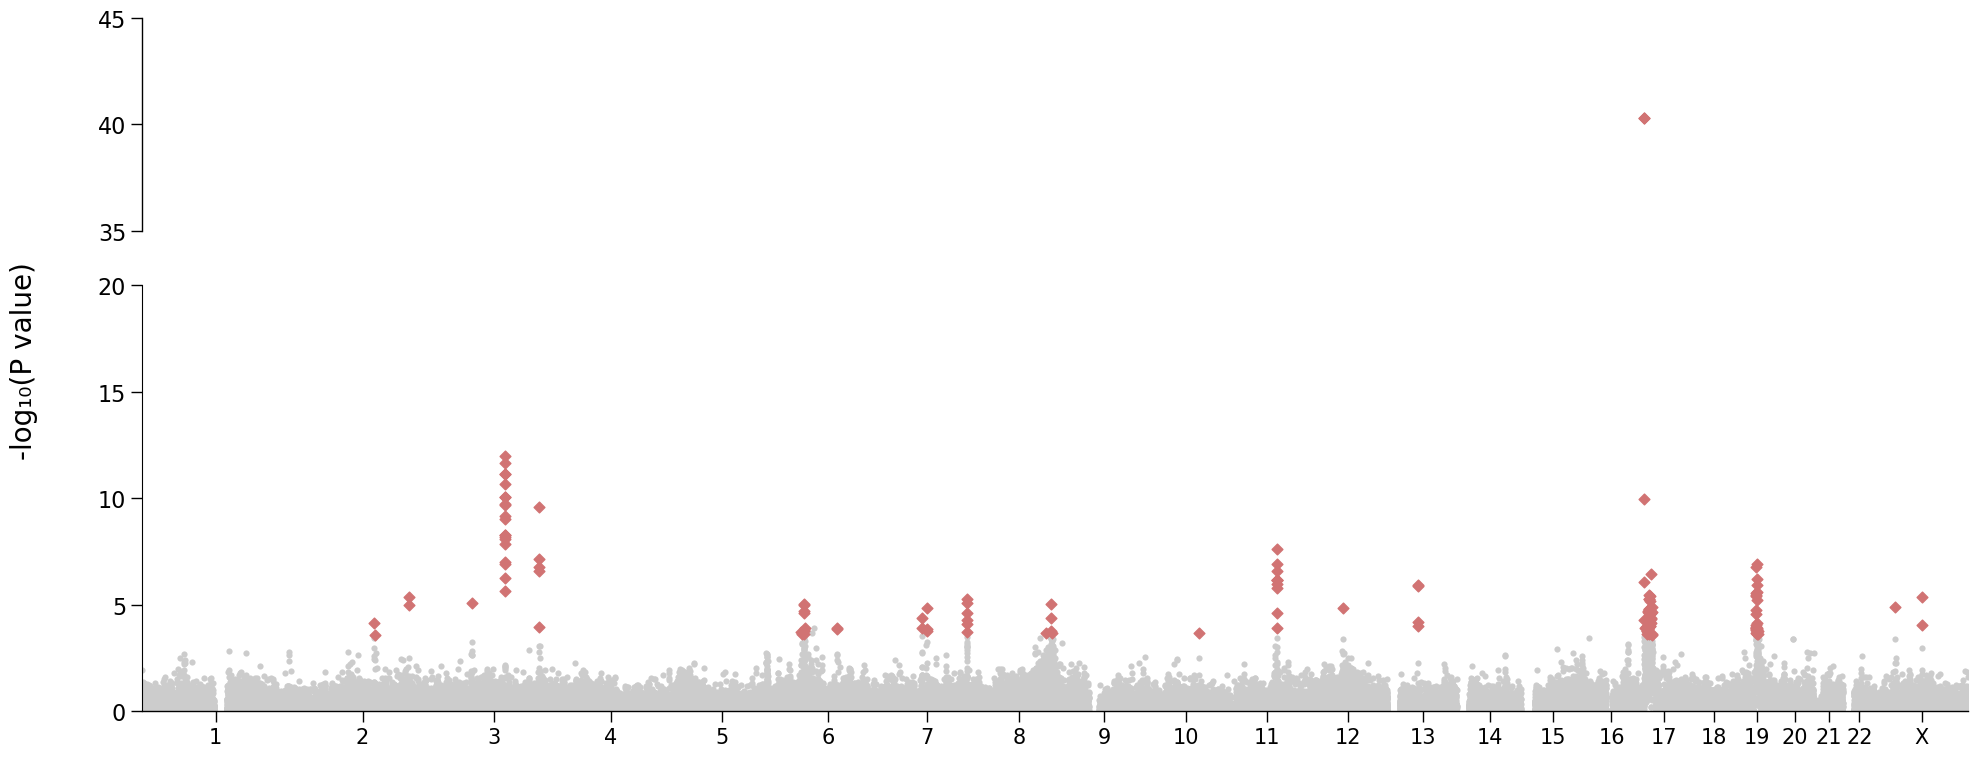

In [ ]:
def make_manhattan_plot_manuscript(results, clustered_srbs):

    chr_order = [str(i) for i in range(1, 23)] + ['X']
    
    def chr_to_sort_key(chr_str):
        chr_clean = chr_str.replace('chr', '')
        if chr_clean == 'X': return 23
        elif chr_clean == 'Y': return 24
        else: return int(chr_clean)
    
    results_plot = results.copy()
    clustered_srbs_plot = clustered_srbs.copy()
    
    results_plot['chr_sort'] = results_plot['chr'].apply(chr_to_sort_key)
    clustered_srbs_plot['chr_sort'] = clustered_srbs_plot['chr'].apply(chr_to_sort_key)
    
    results_plot = results_plot.sort_values(['chr_sort', 'start'])
    clustered_srbs_plot = clustered_srbs_plot.sort_values(['chr_sort', 'start'])
    
    chrom_info = []
    cumulative_pos = 0
    gap_size = 2500000

    for chr_num in chr_order:
        chr_name = f'chr{chr_num}'
        chr_data = results_plot[results_plot['chr'] == chr_name]
        if len(chr_data) > 0:
            chr_length = chr_data['end'].max()
            chr_start = cumulative_pos
            chr_end = cumulative_pos + chr_length
            chrom_info.append({
                'chr': chr_name, 'chr_num': chr_num,
                'chr_sort': chr_to_sort_key(chr_name),
                'start_pos': chr_start, 'end_pos': chr_end,
                'center_pos': chr_start + chr_length / 2,
                'length': chr_length
            })
            results_plot.loc[results_plot['chr'] == chr_name, 'plot_pos'] = \
                chr_start + results_plot.loc[results_plot['chr'] == chr_name, 'start']
            chr_clustered = clustered_srbs_plot[clustered_srbs_plot['chr'] == chr_name]
            if len(chr_clustered) > 0:
                clustered_srbs_plot.loc[clustered_srbs_plot['chr'] == chr_name, 'plot_pos'] = \
                    chr_start + clustered_srbs_plot.loc[clustered_srbs_plot['chr'] == chr_name, 'start']
            cumulative_pos = chr_end + gap_size

    chrom_df = pd.DataFrame(chrom_info)

    # ── break bounds ───────────────────────────────────────────────────────
    BREAK_LO  = 20
    BREAK_HI  = 35
    Y_TOP     = 45   # top of upper panel

    raw_y_all  = -np.log10(results_plot['pvalue'].values)
    raw_y_srbs = -np.log10(clustered_srbs_plot['pvalue'].values)

    # ── two-panel broken axis ──────────────────────────────────────────────
    # Upper panel height proportional to its data range, lower panel to its range
    lower_range = BREAK_LO           # 0–20  → 20 units
    upper_range = Y_TOP - BREAK_HI   # 35–45 → 10 units
    total = lower_range + upper_range

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(22, 9),
        gridspec_kw={'height_ratios': [upper_range / total, lower_range / total]},
        sharex=True
    )
    fig.subplots_adjust(hspace=0.17, left=0.07)   # gap between panels

    for ax in (ax_top, ax_bot):
        ax.set_facecolor('white')
        ax.grid(False)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)

    # hide the facing spines at the break
    ax_top.spines['bottom'].set_visible(False)
    ax_bot.spines['top'].set_visible(False)

    # scatter: background (grey)
    scatter_kw_bg = dict(c='#ccccccff', s=20, linewidths=0, zorder=2)
    ax_top.scatter(results_plot['plot_pos'], raw_y_all, **scatter_kw_bg)
    ax_bot.scatter(results_plot['plot_pos'], raw_y_all, **scatter_kw_bg)

    # scatter: SRBs (red diamonds)
    scatter_kw_srb = dict(c='#d17373ff', marker='D', s=30, zorder=5)
    ax_top.scatter(clustered_srbs_plot['plot_pos'], raw_y_srbs, **scatter_kw_srb)
    ax_bot.scatter(clustered_srbs_plot['plot_pos'], raw_y_srbs, **scatter_kw_srb)

    ax_top.set_ylim(BREAK_HI, Y_TOP)    # 35–45, top panel
    ax_bot.set_ylim(0,        BREAK_LO) # 0–20,  bottom panel
    ax_top.set_xlim(0, chrom_df['end_pos'].max())

    # y ticks
    ax_bot.set_yticks([0, 5, 10, 15, 20])
    ax_top.set_yticks([35, 40, 45])
    for ax in (ax_top, ax_bot):
        ax.set_yticklabels([int(t) for t in ax.get_yticks()], fontsize=16)
        ax.tick_params(axis='y', length=8, width=1, direction='out')
        ax_top.spines['left'].set_linewidth(1)
        ax_bot.spines['bottom'].set_linewidth(1)

    # x-ticks
    tick_positions = chrom_df['center_pos'].values
    tick_labels    = [r['chr_num'] for _, r in chrom_df.iterrows()]
    ax_bot.set_xticks(tick_positions)
    ax_bot.set_xticklabels(tick_labels, fontsize=15)
    ax_bot.tick_params(axis='x', length=8, width=1, direction='out')
    ax_top.tick_params(axis='x', bottom=False)   # hide top panel x ticks

    #fig.text(0.04, 0.5, '-log₁₀(P value)', va='center', rotation='vertical', fontsize=18)
    fig.supylabel('-log₁₀(P value)', fontsize=20, x=0.01)

    plt.savefig('../results/manhattan_plot_manuscript_base.pdf', dpi=300, bbox_inches='tight')
    plt.show()

clustered_srbs = cluster_srbs_in_tads(srbs, tads, cosmic)
make_manhattan_plot_manuscript(results, clustered_srbs)